In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from scipy.stats import zscore
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, auc
import matplotlib.pyplot as plt
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

# Use a Python notebook & Load the dataset

In [32]:
parkinsons_df = pd.read_csv('parkinsons.data')
parkinsons_df.sample(10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
105,phon_R01_S25_3,149.689,160.368,133.608,0.00257,0.00002,0.00116,0.00134,0.00349,0.01346,...,0.01979,0.00578,27.421,1,0.365488,0.719974,-6.997403,0.210279,1.994387,0.112878
38,phon_R01_S08_3,180.198,201.249,175.456,0.00284,0.00002,0.00153,0.00166,0.00459,0.01444,...,0.02177,0.00231,26.738,1,0.403884,0.766209,-6.452058,0.212294,2.269398,0.141929
145,phon_R01_S34_6,223.361,263.872,87.638,0.00352,0.00002,0.00169,0.00188,0.00506,0.02536,...,0.04137,0.01493,20.366,1,0.566849,0.574282,-5.456811,0.345238,2.840556,0.232861
85,phon_R01_S21_2,180.978,200.125,155.495,0.00406,0.00002,0.00220,0.00244,0.00659,0.03852,...,0.06321,0.02782,16.176,1,0.583574,0.727747,-5.657899,0.315903,3.098256,0.200423
180,phon_R01_S44_4,150.440,163.441,144.736,0.00396,0.00003,0.00206,0.00233,0.00619,0.02551,...,0.03964,0.00611,23.133,1,0.352396,0.759320,-6.261446,0.183218,2.264226,0.144105
117,phon_R01_S27_3,170.756,450.247,79.032,0.00555,0.00003,0.00244,0.00261,0.00731,0.01725,...,0.02270,0.01802,25.690,1,0.486738,0.676023,-4.597834,0.372114,2.975889,0.282780
135,phon_R01_S33_2,110.453,127.611,105.554,0.00494,0.00004,0.00244,0.00315,0.00731,0.04128,...,0.06688,0.02529,17.707,1,0.653427,0.706687,-5.333619,0.322044,2.631793,0.228319
63,phon_R01_S17_4,228.832,234.619,223.634,0.00296,0.00001,0.00175,0.00155,0.00526,0.01644,...,0.02647,0.00351,25.964,0,0.256570,0.683296,-7.245620,0.018689,2.498224,0.093534
168,phon_R01_S42_4,197.569,217.627,90.794,0.00803,0.00004,0.00490,0.00448,0.01470,0.02177,...,0.03836,0.01337,19.269,0,0.372222,0.725216,-5.736781,0.164529,2.882450,0.202879
66,phon_R01_S18_1,140.341,159.774,67.021,0.00817,0.00006,0.00430,0.00440,0.01289,0.03198,...,0.05490,0.02183,19.560,1,0.460139,0.720908,-5.409423,0.226850,2.359973,0.226156


# It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset

In [33]:
parkinsons_df.shape

(195, 24)

In [34]:
parkinsons_df.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

In [35]:
parkinsons_df.isna().any()

name                False
MDVP:Fo(Hz)         False
MDVP:Fhi(Hz)        False
MDVP:Flo(Hz)        False
MDVP:Jitter(%)      False
MDVP:Jitter(Abs)    False
MDVP:RAP            False
MDVP:PPQ            False
Jitter:DDP          False
MDVP:Shimmer        False
MDVP:Shimmer(dB)    False
Shimmer:APQ3        False
Shimmer:APQ5        False
MDVP:APQ            False
Shimmer:DDA         False
NHR                 False
HNR                 False
status              False
RPDE                False
DFA                 False
spread1             False
spread2             False
D2                  False
PPE                 False
dtype: bool

# Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations?

In [36]:
parkinsons_df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [37]:
parkinsons_df.std()

MDVP:Fo(Hz)         41.390065
MDVP:Fhi(Hz)        91.491548
MDVP:Flo(Hz)        43.521413
MDVP:Jitter(%)       0.004848
MDVP:Jitter(Abs)     0.000035
MDVP:RAP             0.002968
MDVP:PPQ             0.002759
Jitter:DDP           0.008903
MDVP:Shimmer         0.018857
MDVP:Shimmer(dB)     0.194877
Shimmer:APQ3         0.010153
Shimmer:APQ5         0.012024
MDVP:APQ             0.016947
Shimmer:DDA          0.030459
NHR                  0.040418
HNR                  4.425764
status               0.431878
RPDE                 0.103942
DFA                  0.055336
spread1              1.090208
spread2              0.083406
D2                   0.382799
PPE                  0.090119
dtype: float64

In [38]:
# Rearranging dataframe to keep status at the end
rearranged_df = parkinsons_df.drop("status",axis=1) 

In [39]:
rearranged_df['status']=parkinsons_df['status']

In [40]:
rearranged_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356,-0.383535
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543,-0.166136
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071,-0.380200
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543,0.278220
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162,0.338653
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999,0.266668
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647,0.288698
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005,0.266646
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771,0.367430
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058,0.350697


In [41]:
rearranged_df=rearranged_df.drop('name',axis=1)

In [42]:
rearranged_df[rearranged_df.columns.tolist()]=np.where(rearranged_df[rearranged_df.columns.tolist()].quantile(.75)*1.5<rearranged_df[rearranged_df.columns.tolist()],rearranged_df[rearranged_df.columns.tolist()].median(),rearranged_df[rearranged_df.columns.tolist()])
rearranged_df.std()

MDVP:Fo(Hz)         41.390065
MDVP:Fhi(Hz)        45.037627
MDVP:Flo(Hz)        33.603264
MDVP:Jitter(%)       0.002060
MDVP:Jitter(Abs)     0.000019
MDVP:RAP             0.001097
MDVP:PPQ             0.001087
Jitter:DDP           0.003290
MDVP:Shimmer         0.011247
MDVP:Shimmer(dB)     0.103180
Shimmer:APQ3         0.005963
Shimmer:APQ5         0.005968
MDVP:APQ             0.008775
Shimmer:DDA          0.017890
NHR                  0.008010
HNR                  4.425764
RPDE                 0.103942
DFA                  0.055336
spread1              0.293108
spread2              0.080440
D2                   0.382799
PPE                  0.076632
status               0.431878
dtype: float64

In [43]:
rearranged_df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,177.317056,109.284933,0.005036,0.000035,0.002526,0.002711,0.007579,0.024796,0.229236,...,0.038995,0.012146,21.885974,0.498536,0.718099,-5.763112,0.224218,2.381826,0.197394,0.753846
std,41.390065,45.037627,33.603264,0.002060,0.000019,0.001097,0.001087,0.003290,0.011247,0.103180,...,0.017890,0.008010,4.425764,0.103942,0.055336,0.293108,0.080440,0.382799,0.076632,0.431878
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539,0.000000
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,0.421306,0.674758,-5.720868,0.174351,2.099125,0.137451,1.000000
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052,1.000000
75%,182.769000,211.782500,118.049500,0.006200,0.000050,0.003210,0.003320,0.009630,0.031160,0.275500,...,0.047740,0.016910,25.075500,0.587562,0.761881,-5.720868,0.271960,2.636456,0.243796,1.000000
max,260.105000,272.210000,205.495000,0.011010,0.000080,0.005440,0.005760,0.016330,0.056430,0.517000,...,0.087710,0.038280,33.047000,0.685151,0.825288,-5.720868,0.414758,3.671155,0.378483,1.000000


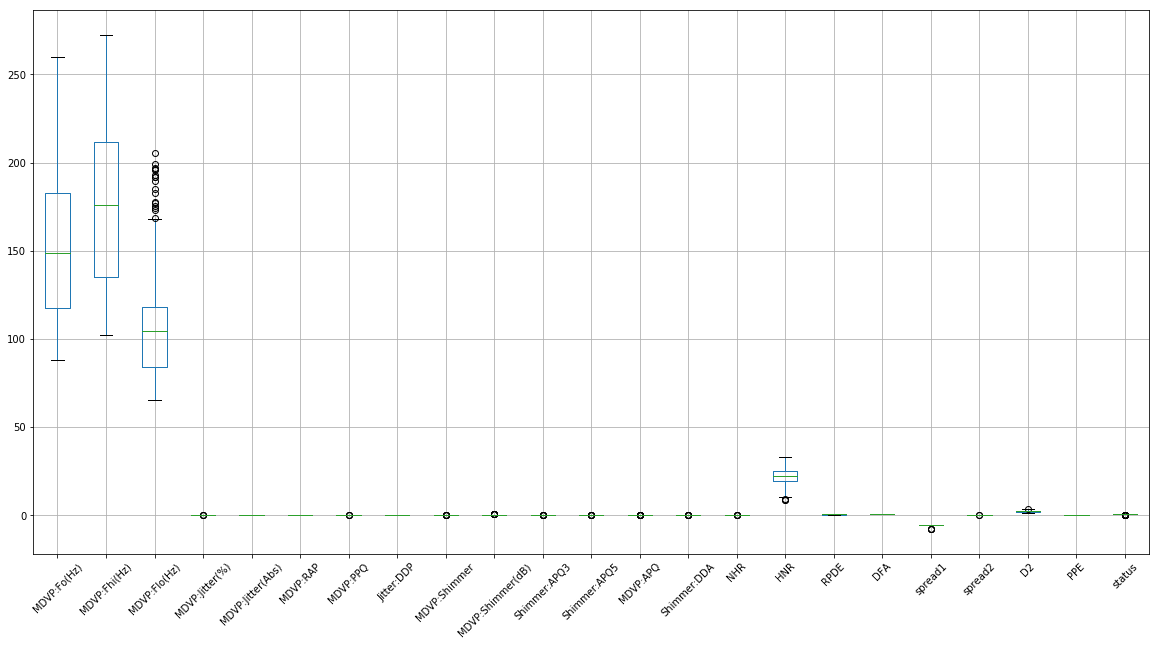

In [44]:
rearranged_df.boxplot(figsize=(20,10),rot=45)

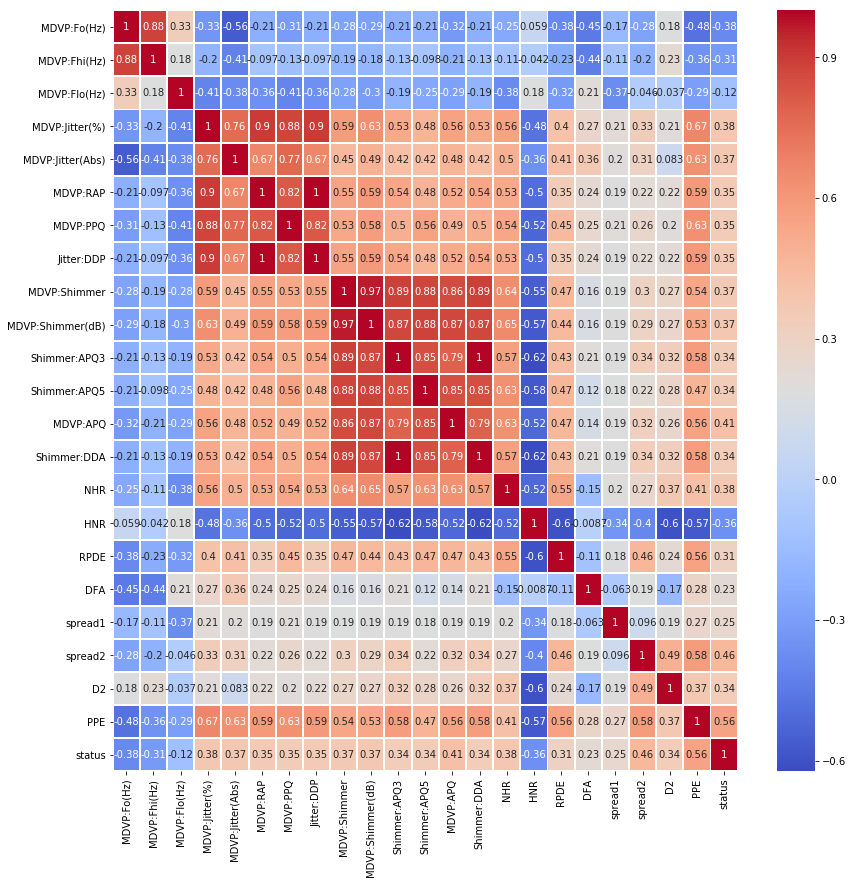

In [45]:
fig, ax = plt.subplots(figsize=(14,14))
sns.heatmap(rearranged_df.corr(), annot=True, linewidths=0.9, ax=ax,cmap='coolwarm')

# Split the dataset into training and test set in the ratio of 70:30

In [46]:

X = rearranged_df.drop("status", axis=1)
y = rearranged_df["status"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Create the model using “entropy” method of reducing the entropy and fit it to training data

In [47]:
model = DecisionTreeClassifier(criterion='entropy',random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab

In [48]:
y_predict = model.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)
metrics.confusion_matrix(y_predict, y_test)

accuracy:  0.864406779661017


array([[11,  7],
       [ 1, 40]])

# Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help?

In [49]:
dt=DecisionTreeClassifier(max_depth=10,min_samples_leaf=5)
dt.fit(X_train,y_train)


DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=10,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=5, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [50]:
y_predict = dt.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)

accuracy:  0.864406779661017


# Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? 

In [51]:
rf=RandomForestClassifier(n_estimators=5,max_depth=5,min_samples_leaf=2)
rf.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=5, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=2, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=5, n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

In [52]:
y_predict = rf.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)

accuracy:  0.8305084745762712
